# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Ridho Firdaus
- **Email:** ridhofirdaus321@gmail.com
- **ID Dicoding:** CDCC288D6Y2497

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana dampak cuaca terhadap penurunan rental sepeda, dan apakah pola tersebut berubah dari tahun 2011 ke 2012?
- **Pertanyaan 2:** Bagaimana perbandingan tren rental sepeda pengguna casual dan registered di tahun 2011 ke 2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
days_df = pd.read_csv('dataset/day.csv')
days_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Data dimulai dari 1 Januari 2011, dengan variasi cuaca dari mendung hingga cerah.
- Data di mulai di musim spring (semi) 2011.
- Rental cenderung lebih banyak saat cuaca cerah.

### Assessing Data

#### Identifying ... problem

In [3]:
days_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
days_df.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


In [5]:
days_df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
days_df.duplicated().sum()

np.int64(0)

In [7]:
# cek value anomali
min_hum = days_df['hum'].min()
days_df[days_df['hum'] == min_hum]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
68,69,2011-03-10,1,0,3,0,4,1,3,0.389091,0.385668,0.0,0.261877,46,577,623


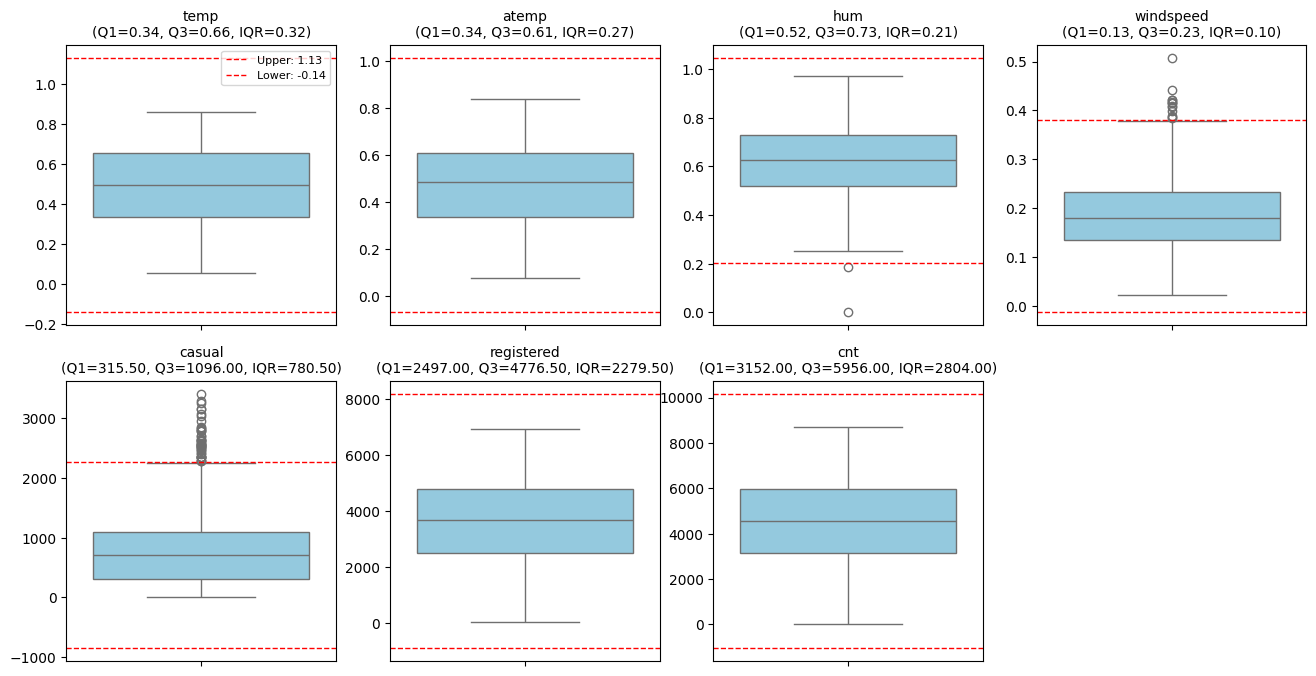

In [8]:
# cek outlier di numeric values
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()


for i, col in enumerate(numeric_cols):
    # Hitung IQR
    Q1 = days_df[col].quantile(0.25)
    Q3 = days_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Buat boxplot
    sns.boxplot(y=days_df[col], ax=axes[i], color='skyblue')
    
    # Tambahkan garis batas outlier
    axes[i].axhline(y=upper_bound, color='red', linestyle='--', linewidth=1, label=f'Upper: {upper_bound:.2f}')
    axes[i].axhline(y=lower_bound, color='red', linestyle='--', linewidth=1, label=f'Lower: {lower_bound:.2f}')
    
    # Set judul
    axes[i].set_title(f'{col}\n(Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f})', fontsize=10)
    axes[i].set_ylabel('')
    
    # Tampilkan legend hanya di subplot pertama
    if i == 0:
        axes[i].legend(fontsize=8)

# Hapus subplot ke-7
fig.delaxes(axes[7])

**Steps to Take:**
- Merubah dteday menjadi datetime
- Invalid Value di humidity(hum) dengan value 0 pada baris dengan index 68, Harus diubah
- Menghapus kolom redundan seperti mnth(month), weekday, dan yr (year) karena value nya nanti bisa di ekstraksi di dteday. Dan instant(index) tidak dibutuhkan

**Insight:** (Opsional)
- Data Bisa dibilang hampir bersih dengan tidak ada nya kolom yang null dan duplikat.
- Tetapi ada beberapa kesalahan seperti invalid values dan struktur data yang salah.
- Terdapat banyak outlier di casual dan windspeed yg melewati batas atas iqr, ini menurut saya bukan kesalahan karena windspeed kencang memang jarang terjadi makanya di boxplot terlihat melewati batas atas. Sama juga dengan casual yang terdapat lonjakan rental sepeda di hari libur. Keputusan Tidak di lakukan apa-apa

### Cleaning Data

#### Fixing ... problem

In [9]:
# merubah dteday
days_df['dteday'] = pd.to_datetime(days_df['dteday'])
days_df['dteday'].head()

0   2011-01-01
1   2011-01-02
2   2011-01-03
3   2011-01-04
4   2011-01-05
Name: dteday, dtype: datetime64[ns]

In [10]:
# Merubah Invalid Value di hum dengan mean hum
mean_hum = days_df[days_df['hum'] > 0]['hum'].mean()
days_df.loc[days_df['hum'] == 0, 'hum'] = mean_hum
days_df.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.628754,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.627500,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.140518,0.077498,686.622488,1560.256377,1937.211452


In [11]:
# hapus kolom yang tidak diperlukan
days_df = days_df.drop(columns=['yr', 'mnth', 'weekday', 'instant'])

**Insight:** (Opsional)
- Anomali/invalid values berhasil di perbaiki.
- perubahan dteday menjadi datetime berhasil

## Exploratory Data Analysis (EDA)

### Explore ...

In [12]:
days_df.describe(include='all')

,dteday,season,holiday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2012-01-01 00:00:00,2.496580,0.028728,0.683995,1.395349,0.495385,0.474354,0.628754,0.190486,848.176471,3656.172367,4504.348837
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,2011-07-02 12:00:00,2.000000,0.000000,0.000000,1.000000,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,2012-01-01 00:00:00,3.000000,0.000000,1.000000,1.000000,0.498333,0.486733,0.627500,0.180975,713.000000,3662.000000,4548.000000
75%,2012-07-01 12:00:00,3.000000,0.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,2012-12-31 00:00:00,4.000000,1.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,NaN,1.110807,0.167155,0.465233,0.544894,0.183051,0.162961,0.140518,0.077498,686.622488,1560.256377,1937.211452


In [13]:
# P1: Rental dengan Cuaca per tahun
tahun = days_df['dteday'].dt.year
days_df.groupby(by=[tahun,"weathersit"]).agg({
    "cnt" : ['mean' , 'sum'],
    "registered" : ['mean', 'sum'],
    'casual' : ['mean' , 'sum']
})

cnt            registered                casual  \
                          mean      sum         mean      sum         mean   
dteday weathersit                                                            
2011   1           3694.986726   835067  2910.597345   657795   784.389381   
       2           3088.096774   382924  2539.814516   314937   548.282258   
       3           1674.133333    25112  1541.266667    23119   132.866667   
2012   1           6003.734177  1422885  4868.400844  1153811  1135.333333   
       2           4991.333333   613934  4163.780488   512145   827.552846   
       3           2126.166667    12757  1809.166667    10855   317.000000   

                           
                      sum  
dteday weathersit          
2011   1           177272  
       2            67987  
       3             1993  
2012   1           269074  
       2           101789  
       3             1902

In [14]:
# P2: Tren Casual vs Registered (2011)

days_df.groupby(by=tahun).agg({
    "registered" : ['mean', 'sum'],
    'casual' : ['mean' , 'sum']
})

registered                casual        
               mean      sum         mean     sum
dteday                                           
2011    2728.358904   995851   677.402740  247252
2012    4581.450820  1676811  1018.483607  372765

### Insight 1: Kondisi Cuaca
- Data hanya mencakup 3 kondisi cuaca (1=Cerah, 2=Kabut, 3=Hujan Ringan)
- Tidak ada data untuk cuaca ekstrem (weathersit=4) karena tidak ada peminjaman


### Insight 2: Pola Casual vs Registered
- Kedua segmen memiliki POLA MUSIMAN yang SAMA (naik di musim panas)
- Registered selalu mendominasi (rasio ~4:1 dibanding casual)
- Casual lebih FLUKTUATIF, Registered lebih STABIL
- Pola ini KONSISTEN di tahun 2011 maupun 2012

## Visualization & Explanatory Analysis

### Pertanyaan 1:

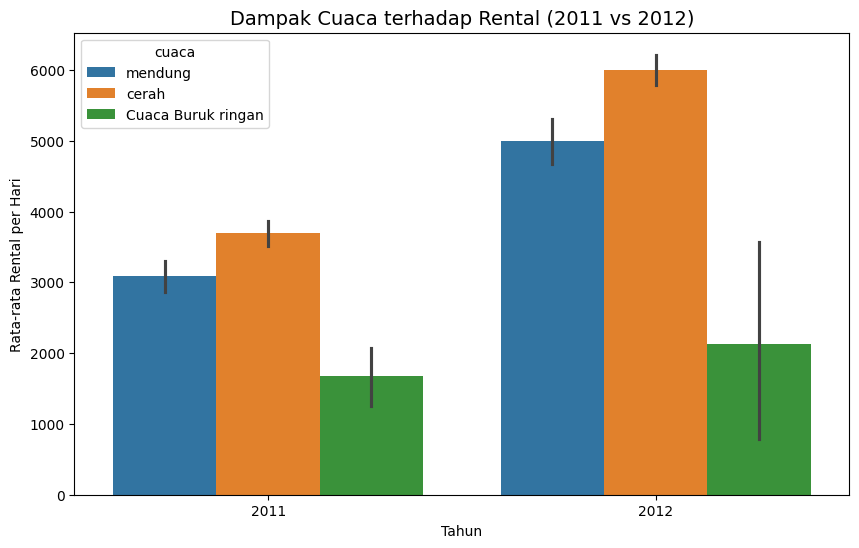

In [15]:
cuaca_df = days_df.copy()
cuaca_df['cuaca'] = cuaca_df['weathersit'].map({1 : "cerah" , 2 : "mendung" , 3 : "Cuaca Buruk ringan" , 4 : "Cuaca Berat"})

plt.figure(figsize=(10,6))
sns.barplot(data = cuaca_df,x=tahun , y="cnt" , hue="cuaca")
plt.title('Dampak Cuaca terhadap Rental (2011 vs 2012)', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Rental per Hari')
plt.show()




### Pertanyaan 2:

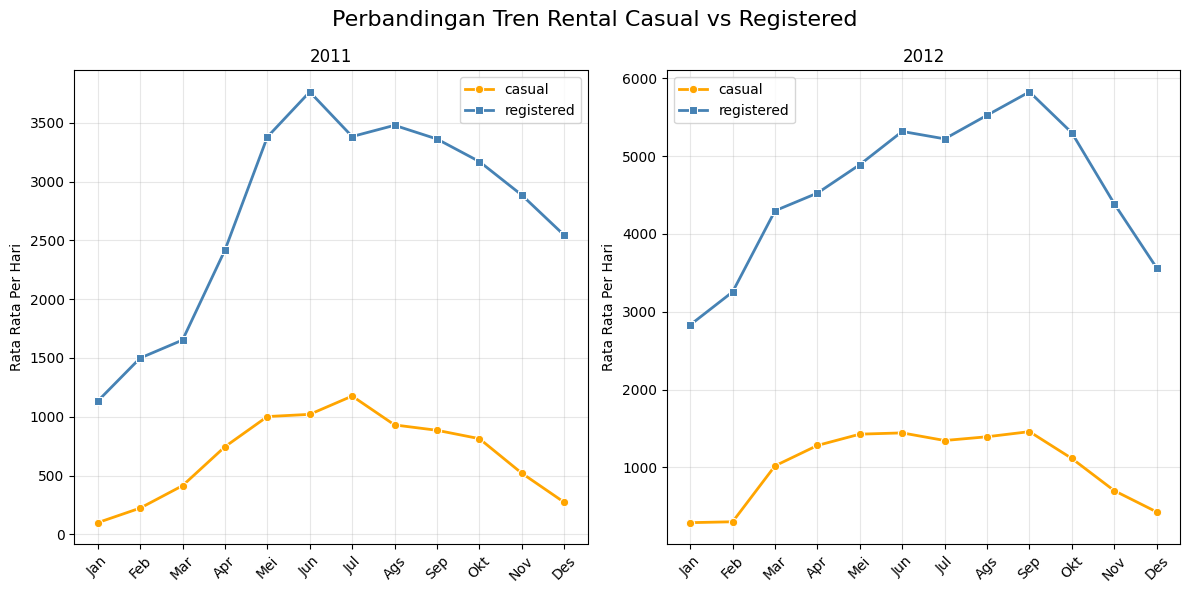

In [16]:
days_df['tahun'] = days_df['dteday'].dt.year
days_df['bulan'] = days_df['dteday'].dt.month
# Hitung rata-rata per bulan
trend_df = days_df.groupby(["tahun", "bulan"])[['casual', 'registered']].mean().reset_index()

# Pisahkan data
trend_2011 = trend_df[trend_df["tahun"] == 2011]
trend_2012 = trend_df[trend_df["tahun"] == 2012]

fig, axes = plt.subplots(1,2, figsize=(12,6))

#plot 2011
sns.lineplot(data=trend_2011, x='bulan' , y='casual', marker='o', ax=axes[0] , linewidth=2, color='orange', label='casual')
sns.lineplot(data=trend_2011, x='bulan' , y='registered', marker='s', ax=axes[0] , linewidth=2, color='steelblue', label='registered')
axes[0].set_title('2011')
axes[0].set_ylabel('Rata Rata Per Hari')
axes[0].set_xlabel('')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des'], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# plot 2012
sns.lineplot(data=trend_2012, x='bulan' , y='casual', marker='o', ax=axes[1] , linewidth=2, color='orange', label='casual')
sns.lineplot(data=trend_2012, x='bulan' , y='registered', marker='s', ax=axes[1] , linewidth=2, color='steelblue', label='registered')
axes[1].set_title('2012')
axes[1].set_ylabel('Rata Rata Per Hari')
axes[1].set_xlabel('')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des'], rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Tren Rental Casual vs Registered', fontsize=16)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Cuaca menentukan customer untuk rental sepeda
- register user lebih mendominasi dibandingkan casual user untuk rental sepeda

## Analisis Lanjutan (Opsional)

In [17]:
# helper function
def cluster_suhu(temp):
    if temp < 0.3 :
        return "dingin"
    elif temp < 0.6 : 
        return "sedang"
    else:
        return "panas"

def cluster_cuaca(weathersit):
    if weathersit == 1:
        return "cerah"
    elif weathersit == 2:
        return "mendung"
    elif weathersit == 3:
        return "cuaca buruk ringan"
    else:
        return "cuaca buruk berat"

def cluster_hari(workingday, holiday):
    if holiday == 1:
        return 'Hari Libur'
    elif workingday == 1:
        return 'Hari Kerja'
    else:
        return 'Akhir Pekan'


In [18]:
# applying clustering
days_df['cluster_suhu'] = days_df['temp'].apply(cluster_suhu)
days_df['cluster_cuaca'] = days_df['weathersit'].apply(cluster_cuaca)
days_df['cluster_hari'] = days_df.apply(lambda x: cluster_hari(x['workingday'], x['holiday']), axis=1)


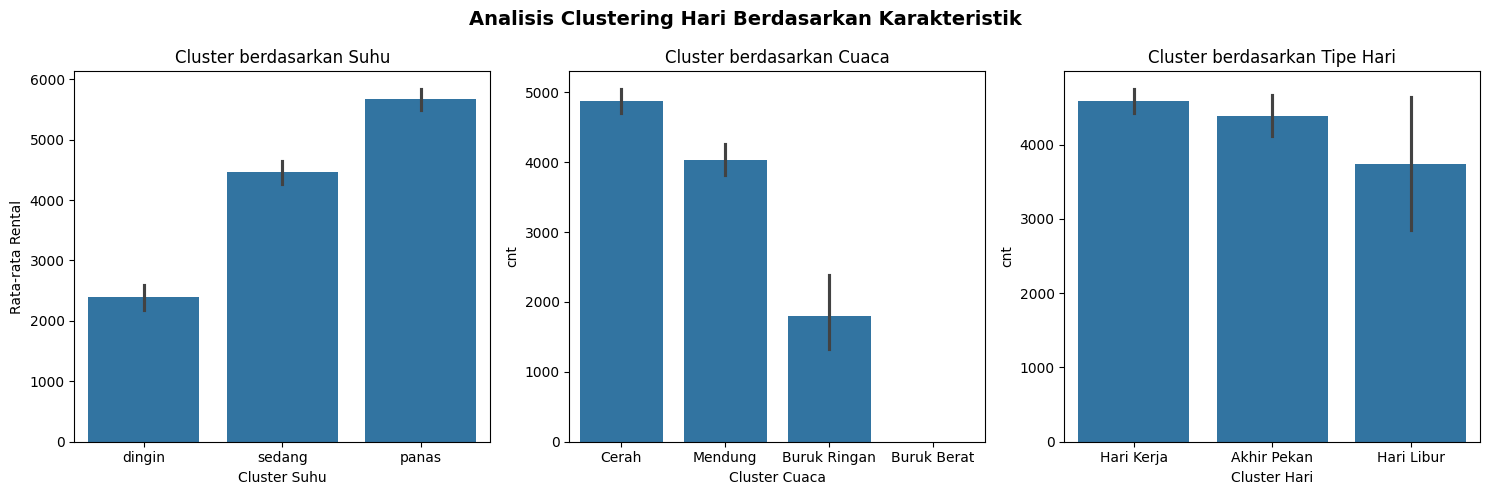

In [19]:
# visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Cluster suhu
sns.barplot(data=days_df, x='cluster_suhu', y='cnt', 
            order=['dingin', 'sedang', 'panas'], ax=axes[0])
axes[0].set_title('Cluster berdasarkan Suhu')
axes[0].set_xlabel('Cluster Suhu')
axes[0].set_ylabel('Rata-rata Rental')

# Plot 2: Cluster cuaca
sns.barplot(data=days_df, x='cluster_cuaca', y='cnt', 
            order=['cerah', 'mendung', 'cuaca buruk ringan' , 'cuaca buruk berat'], ax=axes[1])
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['Cerah', 'Mendung', 'Buruk Ringan', 'Buruk Berat'], rotation=0)
axes[1].set_title('Cluster berdasarkan Cuaca')
axes[1].set_xlabel('Cluster Cuaca')

# Plot 3: Cluster hari
sns.barplot(data=days_df, x='cluster_hari', y='cnt', 
            order=['Hari Kerja', 'Akhir Pekan', 'Hari Libur'], ax=axes[2])
axes[2].set_title('Cluster berdasarkan Tipe Hari')
axes[2].set_xlabel('Cluster Hari')

plt.suptitle('Analisis Clustering Hari Berdasarkan Karakteristik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Tujuan Analisis

Tujuan dari analisis clustering ini adalah untuk **mengelompokkan hari-hari** berdasarkan karakteristik tertentu (cuaca, musim, dan tipe hari) guna mengidentifikasi pola peminjaman sepeda yang lebih mendalam. Dengan mengetahui cluster mana yang memiliki rental tertinggi dan terendah, perusahaan dapat mengambil keputusan bisnis yang lebih tepat sasaran.

### Teknik yang Digunakan: Manual Clustering dengan Binning

**Binning** adalah teknik mengelompokkan data numerik kontinu ke dalam kategori-kategori diskrit berdasarkan batasan nilai (threshold) yang telah ditentukan. Teknik ini dipilih karena:
- Sederhana dan mudah diinterpretasikan
- Tidak memerlukan algoritma machine learning yang kompleks
- Dapat disesuaikan dengan aturan bisnis (business rules)

---

## Conclusion & Recommendation

### 1. Bagaimana dampak cuaca terhadap penurunan rental sepeda, dan apakah pola tersebut berubah dari tahun 2011 ke 2012?
- Cuaca adalah faktor penentu peminjaman sepeda
- Cuaca mendung dan buruk ringan = Rental turun 65% dibanding cerah
- Pola ini konsisten di tahun 2011 dan 2012

### 2. Bagaimana perbandingan tren rental sepeda pengguna casual dan registered di tahun 2011 ke 2012?
- Registered user mendominasi (80% dari total rental)
- Kedua segmen memiliki pola musiman/bulanan yang SAMA
- Casual lebih fluktuatif, Registered lebih stabil

**Rekomendasi Action Item:**
- Siapkan strategi menghadapi cuaca buruk (diskon/promosi) atau kurangi unit sepeda apabila perkiraan cuaca buruk.
- Program konversi casual ke registered user
- Perbanyak Unit sepeda saat perkiraan cuaca baik